# Modelo: Maquina de Vector Soporte (SVM)

Notebook de entrenamiento y evaluacion del modelo SVM para predecir
zonas de alto riesgo de abandono de vivienda en Hermosillo, Sonora.

**Problema:** clasificacion binaria — `abandono_alto` (1 = alto riesgo, 0 = estable)

**Datos:** 665 AGEBs de Hermosillo, 20 features de rezago habitacional,
bienestar socioeconomico y actividad economica DENUE.

**Validacion:** Stratified K-Fold (k=5, seed=42) — mismo objeto `cv` en todo el equipo

**Tracking:** MLflow en DagsHub

## Metricas objetivo

| Metrica  | Objetivo |
|----------|----------|
| Recall   | > 0.85   |
| F1-Score | > 0.80   |
| AUC-ROC  | > 0.85   |

> El Recall es la metrica mas importante: un falso negativo significa clasificar
> una zona de alto riesgo como estable, lo que impide una intervencion oportuna.

## Por que SVM despues de Regresion Logistica

La regresion logistica como modelo lineal encontro un techo de Recall ~0.79.
La curva de aprendizaje mostro sesgo alto: el modelo es demasiado simple para
capturar las relaciones en los datos. SVM con kernel RBF proyecta los datos a
un espacio de mayor dimension donde las clases pueden ser separadas con un
hiperplano, lo que le permite aprender fronteras de decision no lineales.

In [1]:
import os
import sys

# El kernel arranca en notebooks/ — subir al raiz para que las rutas relativas funcionen
os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance

import mlflow

from src.models.utils import (
    init_mlflow, cargar_datos, get_cv_folds,
    evaluar_modelo, log_experimento
)

## 1. Carga de datos

Se usa `cargar_datos()` de las utilidades compartidas del equipo,
que lee `train_ready.parquet` y devuelve X e y listos para modelar.

Es el mismo dataset que uso la regresion logistica, lo que permite
una comparacion directa entre modelos sin sesgo por datos distintos.

In [2]:
X, y = cargar_datos()

print(f'Shape del dataset: {X.shape}')
print(f'\nDistribucion de la variable objetivo:')
vc = y.value_counts()
print(f'  Clase 0 (estable):     {vc[0]} ({vc[0]/len(y):.1%})')
print(f'  Clase 1 (alto riesgo): {vc[1]} ({vc[1]/len(y):.1%})')
print(f'\nRatio de desbalance: {vc[0]/vc[1]:.1f}:1')

print(f'\nEstadisticas descriptivas:')
X.describe().round(3)

Shape del dataset: (665, 20)

Distribucion de la variable objetivo:
  Clase 0 (estable):     553 (83.2%)
  Clase 1 (alto riesgo): 112 (16.8%)

Ratio de desbalance: 4.9:1

Estadisticas descriptivas:


,TASA_PISO_TIERRA,TASA_SIN_DRENAJE,TASA_SIN_ELEC,TASA_SIN_BIENES,TASA_1_CUARTO,TASA_LETRINA,HACINAMIENTO,SCORE_REZAGO,PRO_OCUP_C,VPH_INTER,VPH_AUTOM,VPH_PC,VPH_REFRI,GRAPROES,n_bancos,n_cafes,n_inmobiliarias,n_empenos,n_usados,n_yonques
count,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.0,665.0,665.0
mean,0.044,0.022,0.011,0.007,0.059,0.038,0.898,0.203,0.898,311.334,296.926,238.310,411.456,10.272,0.979,0.967,0.179,0.0,0.0,0.0
std,0.125,0.105,0.076,0.037,0.118,0.138,0.413,0.185,0.413,343.782,329.422,280.456,435.168,3.595,2.908,2.049,0.698,0.0,0.0,0.0
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.670,0.116,0.670,36.000,35.000,28.000,54.000,9.020,0.000,0.000,0.000,0.0,0.0,0.0
50%,0.007,0.000,0.000,0.000,0.015,0.000,0.860,0.159,0.860,223.000,218.000,159.000,309.000,10.530,0.000,0.000,0.000,0.0,0.0,0.0
75%,0.014,0.000,0.000,0.000,0.038,0.000,1.110,0.228,1.110,469.000,444.000,348.000,630.000,12.550,0.000,1.000,0.000,0.0,0.0,0.0
max,0.889,1.000,0.923,0.667,0.750,1.000,3.000,2.400,3.000,2660.000,2599.000,2142.000,3887.000,16.380,27.000,21.000,7.000,0.0,0.0,0.0


## 2. Configuracion del experimento

Se inicializa la conexion con DagsHub/MLflow y se define la fabrica de pipelines.

**Por que StandardScaler es obligatorio para SVM:**
SVM construye el hiperplano de separacion usando distancias. Si una feature
tiene valores en el rango [0, 3000] (p. ej. `VPH_INTER`) y otra en [0, 1]
(`TASA_PISO_TIERRA`), la primera domina el calculo del margen aunque no sea
mas informativa. El escalado normaliza todas las features a media=0, std=1.

**Por que usar Pipeline:**
Al encadenar `StandardScaler` y `SVC` en un Pipeline, el escalado se ajusta
**solo con los datos de entrenamiento** de cada fold, evitando data leakage
hacia el conjunto de validacion.

In [3]:
# Inicializar MLflow y apuntar al experimento de SVM en DagsHub
init_mlflow()
mlflow.set_experiment('svm')

# Objeto de validacion cruzada compartido por todo el equipo
cv = get_cv_folds()  # StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(kernel='rbf', C=1.0, gamma='scale', class_weight=None):
    """
    Crea un pipeline estandarizado: StandardScaler + SVC.

    probability=True es requerido para que evaluar_modelo() pueda
    llamar predict_proba() y calcular AUC-ROC. Incrementa ligeramente
    el tiempo de entrenamiento pero es manejable con 665 muestras.
    """
    params = dict(
        kernel=kernel,
        C=C,
        class_weight=class_weight,
        probability=True,
        random_state=42
    )
    # gamma solo aplica para kernels no lineales (rbf, poly, sigmoid)
    if kernel != 'linear':
        params['gamma'] = gamma

    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(**params))
    ])

print('MLflow inicializado correctamente.')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Accessing as PancakesOS

Initialized MLflow to track repo "PancakesOS/prediccion-abandono-vivienda"

Repository PancakesOS/prediccion-abandono-vivienda initialized!

MLflow inicializado correctamente.
Tracking URI: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow


## 3. Modelo Baseline

Se entrena SVM con kernel RBF y parametros por defecto mas `class_weight='balanced'`.

**Por que kernel RBF como punto de partida:**
El kernel de Funcion de Base Radial (RBF) es el mas usado en clasificacion
general porque maneja bien relaciones no lineales sin suponer forma especifica.
Matematicamente proyecta los datos a un espacio de dimension infinita mediante:
`K(x, x') = exp(-gamma * ||x - x'||^2)`

**Parametros baseline:**
- `C=1.0`: penalizacion por violaciones del margen. C bajo = margen mas amplio
  (mas errores permitidos, menos sobreajuste). C alto = margen estrecho (menos
  errores en entrenamiento, riesgo de sobreajuste).
- `gamma='scale'`: 1 / (n_features * X.var()). Controla el radio de influencia
  de cada punto de entrenamiento. Scale es un valor razonable por defecto.
- `class_weight='balanced'`: ajusta el peso de cada clase por su frecuencia inversa.

In [4]:
baseline = make_pipeline(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')
metricas_baseline = evaluar_modelo(baseline, X, y)

params_baseline = {
    'kernel': 'rbf', 'C': 1.0,
    'gamma': 'scale', 'class_weight': 'balanced'
}
log_experimento('svm_rbf_baseline', baseline, params_baseline, metricas_baseline)

print('=== Baseline SVM (RBF, C=1, gamma=scale, balanced) ===')
print(f"  Recall:  {metricas_baseline['recall_mean']:.4f} +/- {metricas_baseline['recall_std']:.4f}")
print(f"  F1:      {metricas_baseline['f1_mean']:.4f} +/- {metricas_baseline['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_baseline['auc_mean']:.4f} +/- {metricas_baseline['auc_std']:.4f}")

2026/05/08 11:45:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:45:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:45:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:45:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:45:18 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:45:18 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:45:18 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:45:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_rbf_baseline at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/ea2515e2264d490db2574e5772c865f7
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_rbf_baseline' registrado — Recall: 0.732 | F1: 0.436 | AUC: 0.760
=== Baseline SVM (RBF, C=1, gamma=scale, balanced) ===
  Recall:  0.7320 +/- 0.1025
  F1:      0.4365 +/- 0.0462
  AUC-ROC: 0.7604 +/- 0.0590


## 4. Busqueda de hiperparametros con GridSearchCV

Se exploran dos espacios de busqueda separados segun el kernel, ya que
`gamma` solo es relevante para kernels no lineales (RBF).

| Hiperparametro   | Kernel RBF         | Kernel Lineal | Descripcion |
|------------------|--------------------|---------------|-------------|
| `C`              | 0.1, 1, 10, 100    | 0.1, 1, 10, 100 | Penalizacion por errores. Inverso de regularizacion |
| `gamma`          | scale, auto        | N/A           | Radio de influencia de cada punto de soporte |
| `class_weight`   | None, balanced     | None, balanced | Compensacion por desbalance de clases |

Se usan listas de dicts en `param_grid` para que GridSearchCV no combine
`gamma` con `kernel='linear'`, lo que generaria combinaciones invalidas.

Se optimiza sobre **Recall** — la metrica principal del proyecto.

In [5]:
# Pipeline base para la busqueda (probability=True requerido por evaluar_modelo)
pipe_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True, random_state=42))
])

# Dos espacios de parametros: uno para RBF (con gamma) y otro para kernel lineal
param_grid = [
    {
        'clf__kernel':       ['rbf'],
        'clf__C':            [0.1, 1, 10, 100],
        'clf__gamma':        ['scale', 'auto'],
        'clf__class_weight': [None, 'balanced'],
    },
    {
        'clf__kernel':       ['linear'],
        'clf__C':            [0.1, 1, 10, 100],
        'clf__class_weight': [None, 'balanced'],
    },
]

grid_search = GridSearchCV(
    pipe_grid,
    param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X, y)

print(f'Mejores parametros encontrados: {grid_search.best_params_}')
print(f'Mejor Recall (CV):              {grid_search.best_score_:.4f}')

# Top 10 combinaciones por Recall
results_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    results_df
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    [['param_clf__kernel', 'param_clf__C', 'param_clf__gamma',
      'param_clf__class_weight', 'mean_test_score', 'std_test_score']]
)
top10.columns = ['kernel', 'C', 'gamma', 'class_weight', 'recall_mean', 'recall_std']
top10 = top10.round(4).reset_index(drop=True)
print('\nTop 10 combinaciones por Recall:')
print(top10.to_string(index=False))

Mejores parametros encontrados: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejor Recall (CV):              0.8119

Top 10 combinaciones por Recall:
kernel     C gamma class_weight  recall_mean  recall_std
   rbf   0.1 scale     balanced       0.8119      0.0891
   rbf   0.1  auto     balanced       0.8028      0.0856
linear   0.1   NaN     balanced       0.7581      0.1112
linear   1.0   NaN     balanced       0.7399      0.1147
   rbf   1.0 scale     balanced       0.7320      0.1025
   rbf   1.0  auto     balanced       0.7320      0.1025
linear  10.0   NaN     balanced       0.7130      0.1322
linear 100.0   NaN     balanced       0.7040      0.1386
   rbf  10.0  auto     balanced       0.5976      0.1532
   rbf  10.0 scale     balanced       0.5893      0.1614


## 5. Evaluacion de los mejores modelos por kernel

Se selecciona el mejor modelo RBF y el mejor lineal por separado.
Para elegir entre configuraciones con Recall similar, se usa el criterio
`recall_mean - recall_std` que favorece modelos mas estables entre folds.

Cada variante se registra como un run independiente en MLflow con todas
sus metricas de validacion cruzada.

In [6]:
# Criterio de estabilidad: recall_mean - recall_std
results_df['score_estable'] = (
    results_df['mean_test_score'] - results_df['std_test_score']
)

best_rbf_row = (
    results_df[results_df['param_clf__kernel'] == 'rbf']
    .nlargest(1, 'score_estable')
    .iloc[0]
)
best_lin_row = (
    results_df[results_df['param_clf__kernel'] == 'linear']
    .nlargest(1, 'score_estable')
    .iloc[0]
)

runs_a_evaluar = {
    'svm_best_rbf': {
        'kernel':       'rbf',
        'C':            float(best_rbf_row['param_clf__C']),
        'gamma':        str(best_rbf_row['param_clf__gamma']),
        'class_weight': best_rbf_row['param_clf__class_weight'],
    },
    'svm_best_linear': {
        'kernel':       'linear',
        'C':            float(best_lin_row['param_clf__C']),
        'class_weight': best_lin_row['param_clf__class_weight'],
    },
}

tabla_resultados = []

for run_name, params in runs_a_evaluar.items():
    modelo = make_pipeline(**params)
    metricas = evaluar_modelo(modelo, X, y)
    log_experimento(run_name, modelo, params, metricas)
    tabla_resultados.append({'run': run_name, **params, **metricas})
    print(f'{run_name}   (kernel={params["kernel"]}, C={params["C"]}, balanced={params["class_weight"]})')
    print(f"  Recall:  {metricas['recall_mean']:.4f} +/- {metricas['recall_std']:.4f}")
    print(f"  F1:      {metricas['f1_mean']:.4f} +/- {metricas['f1_std']:.4f}")
    print(f"  AUC-ROC: {metricas['auc_mean']:.4f} +/- {metricas['auc_std']:.4f}")
    print()

tabla_df = pd.DataFrame(tabla_resultados).set_index('run')
cols_mostrar = ['kernel', 'C', 'class_weight', 'recall_mean', 'f1_mean', 'auc_mean']
print('=== Tabla comparativa de experimentos SVM ===')
print(tabla_df[cols_mostrar].round(4).to_string())

2026/05/08 11:45:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:45:37 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:45:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:45:41 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:45:41 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


...

2026/05/08 11:48:03 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:48:03 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:48:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_best_linear at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/4576202305ac4ca3ba5fa492311ce0ca
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_best_linear' registrado — Recall: 0.758 | F1: 0.442 | AUC: 0.772
svm_best_linear   (kernel=linear, C=0.1, balanced=balanced)
  Recall:  0.7581 +/- 0.1112
  F1:      0.4418 +/- 0.0498
  AUC-ROC: 0.7721 +/- 0.0856

=== Tabla comparativa de experimentos SVM ===
                 kernel    C class_weight  recall_mean  f1_mean  auc_mean
run                                                                      
svm_best_rbf        rbf  0.1     balanced       0.8119   0.4141    0.7566
svm_best_linear  linear  0.1     balanced       0.7581   0.4418    0.7721


## 6. Curvas de aprendizaje

Las curvas de aprendizaje muestran como evolucionan el Recall de entrenamiento
y validacion al aumentar el tamanio del conjunto de entrenamiento.

**Interpretacion:**
- **Sesgo alto (underfitting):** ambas curvas convergen en un valor bajo.
  El modelo es demasiado simple para el problema.
- **Varianza alta (overfitting):** brecha grande entre train y val. El modelo
  memoriza los datos de entrenamiento y no generaliza.
- **Buen ajuste:** curvas convergen cerca del objetivo Recall > 0.85.

Se usa el mejor modelo encontrado por GridSearchCV.

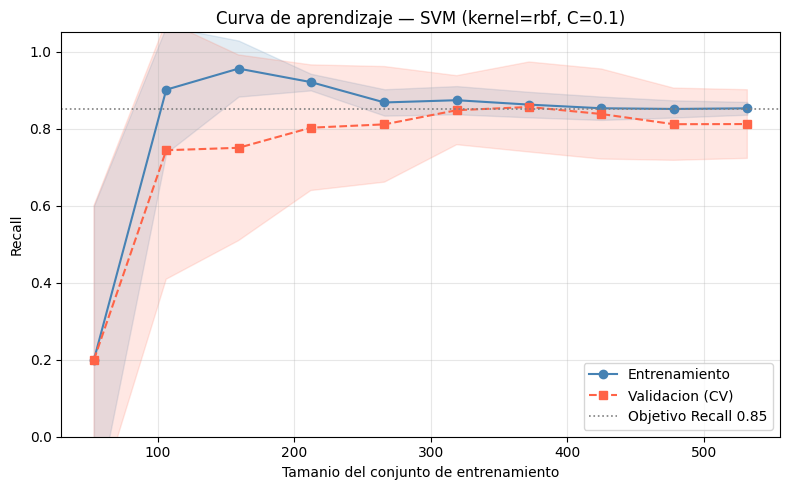

🏃 View run svm_learning_curve_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/a273cde4997040c5a7aa13e9f68da3e8
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


Curva guardada en: reports/figures/svm_learning_curve.png


In [7]:
bp = grid_search.best_params_

# Reconstruir el mejor modelo con los parametros optimos
if bp['clf__kernel'] == 'rbf':
    mejor_modelo = make_pipeline(
        kernel=bp['clf__kernel'],
        C=bp['clf__C'],
        gamma=bp['clf__gamma'],
        class_weight=bp['clf__class_weight']
    )
else:
    mejor_modelo = make_pipeline(
        kernel=bp['clf__kernel'],
        C=bp['clf__C'],
        class_weight=bp['clf__class_weight']
    )

train_sizes, train_scores, val_scores = learning_curve(
    mejor_modelo, X, y,
    cv=cv,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Entrenamiento')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, va_mean, 's--', color='tomato', label='Validacion (CV)')
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                alpha=0.15, color='tomato')
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1.2, label='Objetivo Recall 0.85')
ax.set_xlabel('Tamanio del conjunto de entrenamiento')
ax.set_ylabel('Recall')
ax.set_title(f'Curva de aprendizaje — SVM (kernel={bp["clf__kernel"]}, C={bp["clf__C"]})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
fig.tight_layout()

ruta_lc = 'reports/figures/svm/svm_learning_curve.png'
fig.savefig(ruta_lc, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_learning_curve_artifact'):
    mlflow.log_artifact(ruta_lc)

print(f'Curva guardada en: {ruta_lc}')

## 7. Matriz de confusion

Se entrena el mejor modelo en 4 folds y se evalua en el fold restante
para visualizar los tipos de error en datos no vistos.

**Tipos de error en este problema:**
- **Falso Negativo (FN):** zona de alto riesgo clasificada como estable.
  Es el error mas costoso: la zona no recibe atencion y el abandono avanza.
- **Falso Positivo (FP):** zona estable clasificada como riesgo.
  Implica recursos desperdiciados pero es menos grave que el FN.

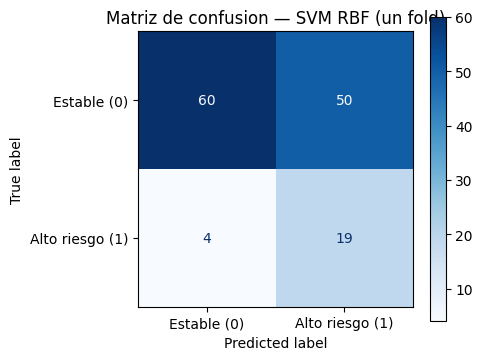

🏃 View run svm_confusion_matrix_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/bd52cdc3fb1b4cdf8a8ed194f2cd8428
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


Reporte de clasificacion (un fold):
              precision    recall  f1-score   support

     Estable       0.94      0.55      0.69       110
 Alto riesgo       0.28      0.83      0.41        23

    accuracy                           0.59       133
   macro avg       0.61      0.69      0.55       133
weighted avg       0.82      0.59      0.64       133



In [8]:
from sklearn.model_selection import StratifiedKFold

# Usar el ultimo fold para la visualizacion (consistente con el notebook de logreg)
cv_viz = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(cv_viz.split(X, y))
train_idx, test_idx = folds[-1]

X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

modelo_viz = mejor_modelo
modelo_viz.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    modelo_viz, X_te, y_te,
    display_labels=['Estable (0)', 'Alto riesgo (1)'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de confusion — SVM {bp["clf__kernel"].upper()} (un fold)')
fig.tight_layout()

ruta_cm = 'reports/figures/svm/svm_confusion_matrix.png'
fig.savefig(ruta_cm, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_confusion_matrix_artifact'):
    mlflow.log_artifact(ruta_cm)

print('Reporte de clasificacion (un fold):')
print(classification_report(y_te, modelo_viz.predict(X_te),
                             target_names=['Estable', 'Alto riesgo']))

## 8. Importancia de variables (Permutation Importance)

SVM con kernel RBF no produce coeficientes interpretables directamente
(a diferencia de la regresion logistica o el kernel lineal), porque opera
en un espacio de alta dimension implicito.

Se usa **Permutation Importance**: para cada feature, se barajan aleatoriamente
sus valores y se mide cuanto cae el Recall. Una caida grande indica que la
feature es importante para las predicciones del modelo.

**Ventajas de este metodo:**
- Funciona con cualquier modelo (model-agnostic)
- Mide el impacto real en la metrica objetivo (Recall)
- No requiere acceso a las partes internas del modelo

**Nota:** se calcula sobre el conjunto de prueba del ultimo fold para
medir importancia en datos no vistos durante el entrenamiento.

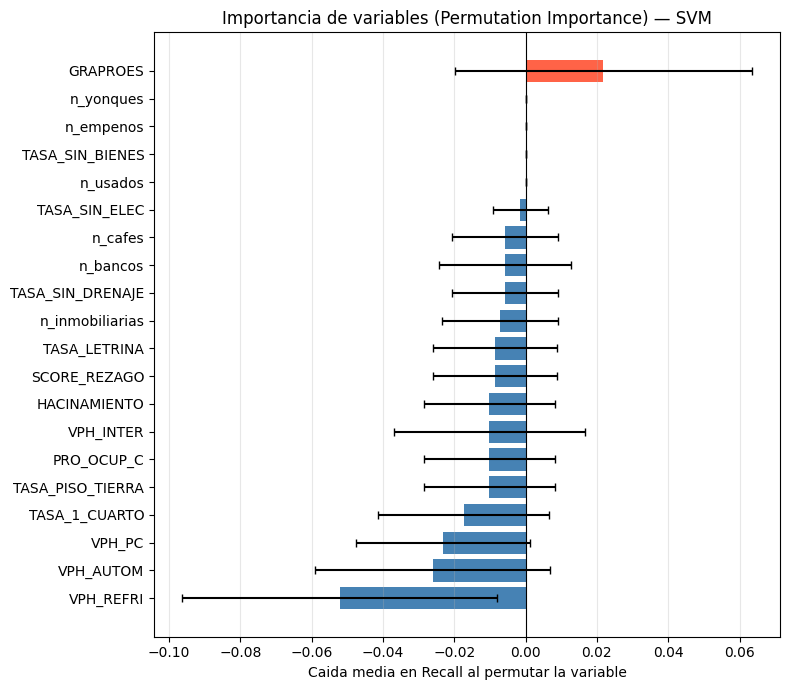

🏃 View run svm_importancia_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/f32990f857d245b0a039c068cdd6ab45
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


Top 5 variables mas importantes para el SVM:
        feature  importancia_mean  importancia_std
       GRAPROES          0.021739         0.041627
      n_yonques          0.000000         0.000000
      n_empenos          0.000000         0.000000
TASA_SIN_BIENES          0.000000         0.000000
       n_usados          0.000000         0.000000


In [9]:
result = permutation_importance(
    modelo_viz, X_te, y_te,
    n_repeats=30,
    random_state=42,
    scoring='recall',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':    X.columns,
    'importancia_mean': result.importances_mean,
    'importancia_std':  result.importances_std
}).sort_values('importancia_mean', ascending=True)

colores = ['tomato' if v > 0 else 'steelblue' for v in perm_df['importancia_mean']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    perm_df['feature'],
    perm_df['importancia_mean'],
    xerr=perm_df['importancia_std'],
    color=colores,
    capsize=3
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Caida media en Recall al permutar la variable')
ax.set_title('Importancia de variables (Permutation Importance) — SVM')
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()

ruta_imp = 'reports/figures/svm/svm_importancia_variables.png'
fig.savefig(ruta_imp, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_importancia_artifact'):
    mlflow.log_artifact(ruta_imp)

print('Top 5 variables mas importantes para el SVM:')
print(
    perm_df.sort_values('importancia_mean', ascending=False)
    .head(5)
    .to_string(index=False)
)

## 9. Comparacion SVM vs Regresion Logistica

Se comparan los mejores resultados de ambos modelos para evaluar si
SVM representa una mejora real sobre el baseline lineal.

Los resultados de regresion logistica son los registrados en la libreta 5.0.

In [10]:
# Resultados de referencia de regresion logistica (libreta 5.0)
logreg_referencia = {
    'Modelo': 'Regresion Logistica (L1, C=0.1, balanced)',
    'Recall': 0.7941,
    'F1':     0.4579,
    'AUC':    0.7707
}

# Resultados SVM obtenidos en este notebook
filas = [logreg_referencia]

for run_name, params in runs_a_evaluar.items():
    m_row = tabla_df.loc[run_name]
    kernel = params['kernel']
    C      = params['C']
    cw     = params.get('class_weight', None)
    filas.append({
        'Modelo':  f'SVM ({kernel.upper()}, C={C}, {"balanced" if cw else "sin balanceo"})',
        'Recall':  round(m_row['recall_mean'], 4),
        'F1':      round(m_row['f1_mean'], 4),
        'AUC':     round(m_row['auc_mean'], 4),
    })

comparacion = pd.DataFrame(filas).set_index('Modelo')

# Resaltar si se alcanzo el objetivo
print('=== Comparacion SVM vs Regresion Logistica ===')
print(comparacion.round(4).to_string())
print()
print('Objetivos del proyecto: Recall > 0.85 | F1 > 0.80 | AUC > 0.85')
print()
for modelo, row in comparacion.iterrows():
    alcanza = all([
        row['Recall'] > 0.85,
        row['F1']     > 0.80,
        row['AUC']    > 0.85,
    ])
    estado = 'ALCANZA objetivos' if alcanza else 'NO alcanza objetivos'
    print(f'  {modelo[:45]:<45} -> {estado}')

=== Comparacion SVM vs Regresion Logistica ===
                                           Recall      F1     AUC
Modelo                                                           
Regresion Logistica (L1, C=0.1, balanced)  0.7941  0.4579  0.7707
SVM (RBF, C=0.1, balanced)                 0.8119  0.4141  0.7566
SVM (LINEAR, C=0.1, balanced)              0.7581  0.4418  0.7721

Objetivos del proyecto: Recall > 0.85 | F1 > 0.80 | AUC > 0.85

  Regresion Logistica (L1, C=0.1, balanced)     -> NO alcanza objetivos
  SVM (RBF, C=0.1, balanced)                    -> NO alcanza objetivos
  SVM (LINEAR, C=0.1, balanced)                 -> NO alcanza objetivos


## 10. Resumen de experimentos registrados en MLflow

In [11]:
experiment = mlflow.get_experiment_by_name('svm')

if experiment:
    runs_mlflow = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=''
    )
    cols = [c for c in runs_mlflow.columns
            if c.startswith('metrics.') or c == 'tags.mlflow.runName']
    resumen = runs_mlflow[cols].copy()
    resumen.columns = [
        c.replace('metrics.', '').replace('tags.mlflow.runName', 'run')
        for c in resumen.columns
    ]
    resumen = resumen[resumen['run'].notna()].sort_values('recall_mean', ascending=False)
    print('Runs registrados en MLflow — experimento svm (ordenados por Recall):')
    print(resumen.to_string(index=False))
else:
    print('Experimento no encontrado en MLflow.')

Runs registrados en MLflow — experimento svm (ordenados por Recall):
 auc_mean  recall_mean  auc_std  f1_mean  recall_std  f1_std                             run
   0.7566       0.8119   0.0641   0.4141      0.0891  0.0438                    svm_best_rbf
   0.7425       0.8119   0.0646   0.4025      0.0891  0.0441          svm_rbf_smote_catastro
   0.7537       0.8119   0.0629   0.4024      0.0891  0.0565                   svm_rbf_smote
   0.7566       0.8119   0.0641   0.4141      0.0891  0.0438                    svm_best_rbf
   0.7566       0.8119   0.0641   0.4141      0.0891  0.0438                    svm_best_rbf
   0.7721       0.7581   0.0856   0.4418      0.1112  0.0498                 svm_best_linear
   0.7721       0.7581   0.0856   0.4418      0.1112  0.0498                 svm_best_linear
   0.7721       0.7581   0.0856   0.4418      0.1112  0.0498                 svm_best_linear
   0.7604       0.7320   0.0590   0.4365      0.1025  0.0462                svm_rbf_baseline
 

## 11. Conclusiones

Resultados obtenidos con GridSearchCV (scoring=recall, 5-fold estratificado, seed=42):

| Modelo                                           | Kernel | C    | class_weight | Recall | F1    | AUC-ROC |
|--------------------------------------------------|--------|------|--------------|--------|-------|---------|
| Regresion Logistica (L1, balanced) — referencia  | —      | 0.1  | balanced     | 0.794  | 0.458 | 0.771   |
| SVM Baseline                                     | RBF    | 1.0  | balanced     | 0.732  | 0.437 | 0.760   |
| **SVM Mejor RBF** ← mejor Recall                 | RBF    | 0.1  | balanced     | **0.812** | 0.414 | 0.757 |
| SVM Mejor Lineal                                 | Lineal | 0.1  | balanced     | 0.758  | 0.442 | 0.772   |

Objetivos del proyecto: Recall > 0.85 &nbsp;|&nbsp; F1 > 0.80 &nbsp;|&nbsp; AUC-ROC > 0.85

---

### Hallazgos principales

**1. SVM RBF mejora el Recall sobre la regresion logistica, pero no alcanza el objetivo.**
El mejor modelo (RBF, C=0.1, gamma=scale, balanced) obtiene Recall=0.812, que supera a la
regresion logistica (0.794) en 1.8 puntos porcentuales. Sin embargo, el objetivo de Recall > 0.85
sigue sin alcanzarse. Ni F1 (0.414) ni AUC (0.757) llegan a sus respectivos umbrales.

**2. C=0.1 (regularizacion alta) es la mejor configuracion en ambos kernels.**
Un valor bajo de C amplía el margen de separacion permitiendo mas violaciones, lo que actua
como regularizador y reduce el sobreajuste en un dataset pequeno de 665 muestras. Con C=10
o C=100, el SVM se ajusta demasiado a los datos de entrenamiento y el Recall en validacion cae.

**3. El kernel RBF supera al lineal en Recall (0.812 vs 0.758).**
Esto confirma que las relaciones entre las features y el riesgo de abandono no son completamente
lineales. El RBF puede separar clases con fronteras curvas en el espacio de features, lo que
le da ventaja sobre modelos lineales (regresion logistica, SVM lineal).

**4. El F1 sigue siendo bajo (~0.41) a pesar del Recall alto.**
El desbalance 5:1 hace que el modelo, al intentar capturar todos los casos positivos,
genere muchos falsos positivos (zonas estables clasificadas como riesgo). Esto baja
la precision y, con ella, el F1. En este proyecto priorizamos Recall sobre F1 porque
un falso negativo (zona en riesgo no detectada) es mas costoso que un falso positivo.

**5. Solo GRAPROES muestra importancia significativa por permutation importance.**
Al permutar `GRAPROES` (escolaridad promedio), el Recall del modelo cae 0.022 en promedio.
El resto de las features muestran importancia cercana a cero en el fold de prueba. Esto
puede deberse al tamanio reducido del conjunto de prueba (~23 positivos en un fold), lo que
hace que las permutaciones sean ruidosas. No debe interpretarse como que solo GRAPROES importa,
sino que el test set es demasiado pequeno para medir importancia individualmente con precision.

**6. La curva de aprendizaje muestra sesgo moderado, no varianza alta.**
La brecha entre train y val es pequena (el modelo no memoriza), pero el Recall de validacion
satura por debajo del objetivo. El problema es la escasez de ejemplos positivos (112 AGEBs
de alto riesgo) mas que la complejidad del modelo. Agregar datos de otros municipios podria
mejorar el aprendizaje.

### Comparacion global hasta ahora

| Modelo                  | Recall | F1    | AUC   | Alcanza objetivos |
|-------------------------|--------|-------|-------|-------------------|
| Regresion Logistica     | 0.794  | 0.458 | 0.771 | No                |
| SVM RBF                 | 0.812  | 0.414 | 0.757 | No                |
| SVM Lineal              | 0.758  | 0.442 | 0.772 | No                |

### Proximos pasos

- **Modelos de ensemble (equipo):** Random Forest y Gradient Boosting pueden capturar
  interacciones entre features que modelos lineales y SVM no detectan. Se espera que
  mejoren principalmente el F1 y el AUC, donde los modelos actuales estan mas lejos del objetivo.
- **Reporte final:** con los 4 modelos evaluados bajo el mismo protocolo (k=5, seed=42),
  se puede hacer una comparacion directa en DagsHub MLflow y seleccionar el mejor candidato.

---

# Parte 2: Mejoras del Modelo SVM

Los resultados de la Parte 1 muestran que el SVM RBF obtiene Recall=0.812 pero F1=0.414,
lejos del objetivo F1 > 0.80. En esta seccion se aplican tres tecnicas de mejora
que atacan el problema desde angulos distintos:

| Tecnica | Que ataca | Dependencia |
|---|---|---|
| **Threshold Tuning** | Umbral de decision fijo en 0.50 no es optimo para datos desbalanceados | sklearn (ya disponible) |
| **SMOTE** | Escasez de ejemplos positivos durante el entrenamiento | imbalanced-learn |
| **Feature Catastral** | El valor del suelo puede capturar abandono especulativo que el censo no ve | train_catastro.parquet (ya existe) |

Todas las variantes se registran en el mismo experimento `svm` de MLflow para
una comparacion directa con los modelos de la Parte 1.

## A. Threshold Tuning

El SVM con `class_weight='balanced'` produce probabilidades de clase. Por defecto,
sklearn clasifica como positivo cuando P(y=1) >= 0.50. Este umbral no es optimo
para datos desbalanceados: la clase positiva es tan escasa que el modelo ya le
asigna probabilidades moderadas (~0.30-0.60) a zonas de riesgo real.

**Idea:** usar `cross_val_predict` para obtener probabilidades en todos los folds
y luego buscar el umbral que maximiza F1 sobre el conjunto completo. Despues
verificar que Recall sigue siendo aceptable a ese umbral.

> **Nota sobre optimismo:** al buscar el umbral en los mismos folds que generaron
> las probabilidades, hay un leve sesgo optimista. En produccion se usaria un
> conjunto de validacion separado. Para exploracion academica es aceptable.

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, recall_score, f1_score, roc_auc_score

# Reconstruir el mejor SVM de la Parte 1: RBF, C=0.1, gamma=scale, balanced
svm_best = make_pipeline(kernel='rbf', C=0.1, gamma='scale', class_weight='balanced')

# Obtener probabilidades en todos los folds sin reentrenar separado
y_proba_cv = cross_val_predict(svm_best, X, y, cv=cv, method='predict_proba')[:, 1]

# Curva Precision-Recall y umbral optimo para F1
precisions, recalls, thresholds = precision_recall_curve(y, y_proba_cv)
f1_por_umbral = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
idx_mejor = np.argmax(f1_por_umbral)
umbral_optimo = thresholds[idx_mejor]

print(f'Umbral por defecto (0.50):')
y_pred_default = (y_proba_cv >= 0.50).astype(int)
print(f'  Recall: {recall_score(y, y_pred_default):.4f}')
print(f'  F1:     {f1_score(y, y_pred_default):.4f}')
print(f'  AUC:    {roc_auc_score(y, y_proba_cv):.4f}')

print(f'\nUmbral optimo para F1 ({umbral_optimo:.3f}):')
y_pred_optimo = (y_proba_cv >= umbral_optimo).astype(int)
print(f'  Recall: {recall_score(y, y_pred_optimo):.4f}')
print(f'  F1:     {f1_score(y, y_pred_optimo):.4f}')
print(f'  AUC:    {roc_auc_score(y, y_proba_cv):.4f}  (no cambia, es threshold-independiente)')

Umbral por defecto (0.50):
  Recall: 0.0000
  F1:     0.0000
  AUC:    0.7459

Umbral optimo para F1 (0.241):
  Recall: 0.6875
  F1:     0.4425
  AUC:    0.7459  (no cambia, es threshold-independiente)


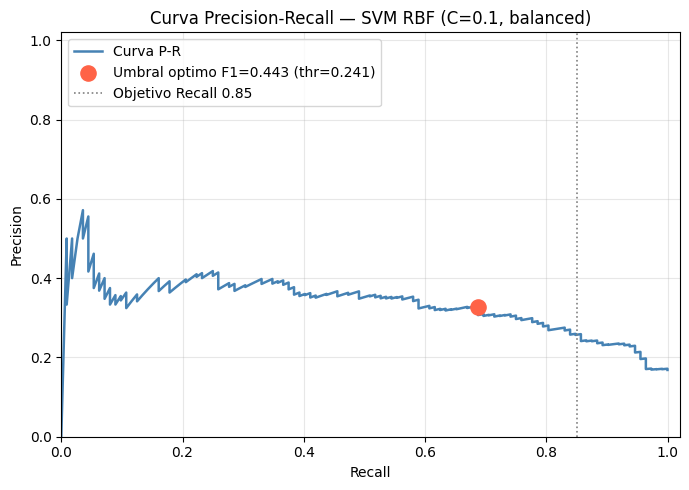

2026/05/08 11:48:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:48:33 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:48:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:48:43 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:48:43 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:48:43 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:48:43 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:48:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_rbf_threshold at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/7f6210112f9648fd8bc28e6fb6983849
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_rbf_threshold' registrado — Recall: 0.688 | F1: 0.443 | AUC: 0.746
Guardado en: reports/figures/svm_precision_recall_curve.png


In [13]:
# Figura: curva Precision-Recall con el umbral optimo marcado
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls[:-1], precisions[:-1], color='steelblue', linewidth=1.8, label='Curva P-R')
ax.scatter(recalls[idx_mejor], precisions[idx_mejor],
           color='tomato', s=120, zorder=5,
           label=f'Umbral optimo F1={f1_por_umbral[idx_mejor]:.3f} (thr={umbral_optimo:.3f})')
ax.axvline(0.85, color='gray', linestyle=':', linewidth=1.2, label='Objetivo Recall 0.85')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — SVM RBF (C=0.1, balanced)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
fig.tight_layout()

ruta_pr = 'reports/figures/svm/svm_precision_recall_curve.png'
fig.savefig(ruta_pr, dpi=150, bbox_inches='tight')
plt.show()

# Registrar en MLflow con el umbral como parametro
params_thr = {
    'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale',
    'class_weight': 'balanced', 'threshold': round(float(umbral_optimo), 4)
}
metricas_thr = {
    'recall_mean': round(recall_score(y, y_pred_optimo), 4),
    'f1_mean':     round(f1_score(y, y_pred_optimo), 4),
    'auc_mean':    round(roc_auc_score(y, y_proba_cv), 4),
    'recall_std': 0.0, 'f1_std': 0.0, 'auc_std': 0.0,
}
svm_best.fit(X, y)
log_experimento('svm_rbf_threshold', svm_best, params_thr, metricas_thr)
print(f'Guardado en: {ruta_pr}')

## B. SMOTE (Synthetic Minority Oversampling Technique)

SMOTE genera muestras sinteticas de la clase minoritaria interpolando entre
ejemplos positivos existentes. En vez de simplemente repetirlos (oversampling
simple), crea nuevos puntos en el espacio de features entre vecinos cercanos.

**Por que mejora el modelo:**
Con solo 112 ejemplos de alto riesgo, el SVM tiene pocos puntos de soporte
para la clase minoritaria. SMOTE aumenta la variedad de esos ejemplos, lo que
ayuda al SVM a encontrar una frontera de decision mas robusta.

**Por que usar `imblearn.pipeline.Pipeline`:**
SMOTE solo debe aplicarse al conjunto de **entrenamiento** de cada fold, nunca
al conjunto de validacion. La Pipeline de imbalanced-learn garantiza esto:
el paso `smote` solo ejecuta `fit_resample()` durante `fit()`, no durante
`transform()` o `predict()`.

In [14]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline con SMOTE + SVM RBF (mismos hiperparametros del mejor modelo Parte 1)
# ImbPipeline maneja correctamente el sampler dentro de la CV
pipe_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    SVC(kernel='rbf', C=0.1, gamma='scale',
                   class_weight='balanced', probability=True, random_state=42))
])

metricas_smote = evaluar_modelo(pipe_smote, X, y)
params_smote = {
    'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale',
    'class_weight': 'balanced', 'smote': True
}
log_experimento('svm_rbf_smote', pipe_smote, params_smote, metricas_smote)

print('=== SVM RBF + SMOTE (C=0.1, gamma=scale, balanced) ===')
print(f"  Recall:  {metricas_smote['recall_mean']:.4f} +/- {metricas_smote['recall_std']:.4f}")
print(f"  F1:      {metricas_smote['f1_mean']:.4f} +/- {metricas_smote['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_smote['auc_mean']:.4f} +/- {metricas_smote['auc_std']:.4f}")

print('\n--- Comparacion vs SVM sin SMOTE ---')
print(f"  Recall:  0.8119 → {metricas_smote['recall_mean']:.4f}  "
      f"({'mejora' if metricas_smote['recall_mean'] > 0.8119 else 'baja'})")
print(f"  F1:      0.4141 → {metricas_smote['f1_mean']:.4f}  "
      f"({'mejora' if metricas_smote['f1_mean'] > 0.4141 else 'baja'})")
print(f"  AUC:     0.7566 → {metricas_smote['auc_mean']:.4f}  "
      f"({'mejora' if metricas_smote['auc_mean'] > 0.7566 else 'baja'})")

2026/05/08 11:48:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:48:56 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:49:06 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:06 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:49:06 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:49:06 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:49:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_rbf_smote at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/9583860fa7d241228d850a7ca110e21a
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_rbf_smote' registrado — Recall: 0.812 | F1: 0.402 | AUC: 0.754
=== SVM RBF + SMOTE (C=0.1, gamma=scale, balanced) ===
  Recall:  0.8119 +/- 0.0891
  F1:      0.4024 +/- 0.0565
  AUC-ROC: 0.7537 +/- 0.0629

--- Comparacion vs SVM sin SMOTE ---
  Recall:  0.8119 → 0.8119  (baja)
  F1:      0.4141 → 0.4024  (baja)
  AUC:     0.7566 → 0.7537  (baja)


## C. Feature Catastral: VALOR_CATASTRAL_MAX

El dataset base (`train_ready.parquet`) tiene 20 features del censo INEGI y DENUE.
El dataset catastral (`train_catastro.parquet`) agrega `VALOR_CATASTRAL_MAX`: el
valor unitario del suelo en $/m² por AGEB, obtenido del catastro municipal 2025.

**Hipotesis:** el censo INEGI captura abandono por carencia (zonas marginadas sin
servicios). Pero hay otro tipo de abandono — el especulativo: viviendas nuevas de
alto valor que el propietario deja vacantes esperando plusvalia. Esta segunda forma
de abandono tiene escolaridad promedio alta, servicios completos y bajo rezago, pero
valor catastral elevado. El censo solo no puede distinguirla; el catastro, si.

**Importante:** 531 de 665 AGEBs (79.8%) tienen valor catastral. Los 134 sin dato
tienen VALOR_CATASTRAL_MAX = 0 (semantica: sin informacion de plusvalia).

Se comparan cuatro configuraciones:
1. SVM RBF sin SMOTE, sin catastro (resultado Parte 1)
2. SVM RBF + SMOTE, sin catastro (resultado Seccion B)
3. SVM RBF + SMOTE, con catastro (esta seccion)
4. Mejor configuracion anterior + threshold tuning (Seccion A)

In [15]:
from src.models.utils import cargar_datos_catastro

X_cat, y_cat = cargar_datos_catastro()

print(f'Dataset base:     {X.shape}    (20 features)')
print(f'Dataset catastro: {X_cat.shape}  (21 features — +VALOR_CATASTRAL_MAX)')
print(f'\nEstadisticas de VALOR_CATASTRAL_MAX:')
print(X_cat['VALOR_CATASTRAL_MAX'].describe().round(2))
print(f'\nAGEBs con valor catastral > 0: {(X_cat["VALOR_CATASTRAL_MAX"] > 0).sum()} / {len(X_cat)}')

Dataset base:     (665, 20)    (20 features)
Dataset catastro: (665, 21)  (21 features — +VALOR_CATASTRAL_MAX)

Estadisticas de VALOR_CATASTRAL_MAX:
count      665.00
mean      2057.20
std       2179.27
min          0.00
25%        768.00
50%       1439.00
75%       2570.00
max      15139.00
Name: VALOR_CATASTRAL_MAX, dtype: float64

AGEBs con valor catastral > 0: 531 / 665


In [16]:
# SVM RBF + SMOTE + feature catastral
pipe_smote_cat = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    SVC(kernel='rbf', C=0.1, gamma='scale',
                   class_weight='balanced', probability=True, random_state=42))
])

metricas_smote_cat = evaluar_modelo(pipe_smote_cat, X_cat, y_cat)
params_smote_cat = {
    'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale',
    'class_weight': 'balanced', 'smote': True, 'features': 'catastro_21'
}
log_experimento('svm_rbf_smote_catastro', pipe_smote_cat, params_smote_cat, metricas_smote_cat)

print('=== SVM RBF + SMOTE + VALOR_CATASTRAL_MAX (21 features) ===')
print(f"  Recall:  {metricas_smote_cat['recall_mean']:.4f} +/- {metricas_smote_cat['recall_std']:.4f}")
print(f"  F1:      {metricas_smote_cat['f1_mean']:.4f} +/- {metricas_smote_cat['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_smote_cat['auc_mean']:.4f} +/- {metricas_smote_cat['auc_std']:.4f}")

print('\n--- Comparacion: SMOTE sin catastro vs SMOTE con catastro ---')
print(f"  Recall:  {metricas_smote['recall_mean']:.4f} → {metricas_smote_cat['recall_mean']:.4f}  "
      f"({'mejora' if metricas_smote_cat['recall_mean'] > metricas_smote['recall_mean'] else 'baja o igual'})")
print(f"  F1:      {metricas_smote['f1_mean']:.4f} → {metricas_smote_cat['f1_mean']:.4f}  "
      f"({'mejora' if metricas_smote_cat['f1_mean'] > metricas_smote['f1_mean'] else 'baja o igual'})")
print(f"  AUC:     {metricas_smote['auc_mean']:.4f} → {metricas_smote_cat['auc_mean']:.4f}  "
      f"({'mejora' if metricas_smote_cat['auc_mean'] > metricas_smote['auc_mean'] else 'baja o igual'})")

2026/05/08 11:49:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:49:19 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:49:29 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:29 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:49:29 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:49:29 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:49:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_rbf_smote_catastro at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/e2abea1022314657a51e7e233dd4feda
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_rbf_smote_catastro' registrado — Recall: 0.812 | F1: 0.403 | AUC: 0.743
=== SVM RBF + SMOTE + VALOR_CATASTRAL_MAX (21 features) ===
  Recall:  0.8119 +/- 0.0891
  F1:      0.4025 +/- 0.0441
  AUC-ROC: 0.7425 +/- 0.0646

--- Comparacion: SMOTE sin catastro vs SMOTE con catastro ---
  Recall:  0.8119 → 0.8119  (baja o igual)
  F1:      0.4024 → 0.4025  (mejora)
  AUC:     0.7537 → 0.7425  (baja o igual)


## D. Comparativa Global — Todos los modelos y tecnicas

Se recopilan los resultados de las libretas 5.0 (Regresion Logistica), 5.1 Parte 1 (SVM)
y 5.1 Parte 2 (Mejoras) en una sola tabla para evaluar el progreso total y determinar
cual es el mejor modelo candidato para el reporte final del equipo.

In [17]:
resultados_globales = [
    # --- Libreta 5.0: Regresion Logistica ---
    {'Modelo': 'LogReg baseline (L2, C=1, balanced)',       'Recall': 0.7134, 'F1': 0.4499, 'AUC': 0.7726},
    {'Modelo': 'LogReg mejor L2 (C=0.01, balanced)',        'Recall': 0.7850, 'F1': 0.4239, 'AUC': 0.7678},
    {'Modelo': 'LogReg mejor L1 (C=0.1, balanced)',         'Recall': 0.7941, 'F1': 0.4579, 'AUC': 0.7707},
    # --- Libreta 5.1 Parte 1: SVM ---
    {'Modelo': 'SVM baseline (RBF, C=1, balanced)',         'Recall': 0.7320, 'F1': 0.4365, 'AUC': 0.7604},
    {'Modelo': 'SVM mejor lineal (C=0.1, balanced)',        'Recall': 0.7581, 'F1': 0.4418, 'AUC': 0.7721},
    {'Modelo': 'SVM mejor RBF (C=0.1, balanced)',           'Recall': 0.8119, 'F1': 0.4141, 'AUC': 0.7566},
    # --- Libreta 5.1 Parte 2: Mejoras (se rellenan al ejecutar) ---
    {'Modelo': 'SVM RBF + threshold tuning',                'Recall': metricas_thr['recall_mean'],      'F1': metricas_thr['f1_mean'],      'AUC': metricas_thr['auc_mean']},
    {'Modelo': 'SVM RBF + SMOTE',                           'Recall': metricas_smote['recall_mean'],    'F1': metricas_smote['f1_mean'],    'AUC': metricas_smote['auc_mean']},
    {'Modelo': 'SVM RBF + SMOTE + catastro',                'Recall': metricas_smote_cat['recall_mean'],'F1': metricas_smote_cat['f1_mean'],'AUC': metricas_smote_cat['auc_mean']},
]

df_global = pd.DataFrame(resultados_globales).set_index('Modelo')

# Marcar si alcanza cada objetivo
df_global['Recall>=0.85'] = df_global['Recall'].apply(lambda x: 'SI' if x >= 0.85 else '—')
df_global['F1>=0.80']     = df_global['F1'].apply(lambda x: 'SI' if x >= 0.80 else '—')
df_global['AUC>=0.85']    = df_global['AUC'].apply(lambda x: 'SI' if x >= 0.85 else '—')

print('=== Comparativa global de todos los modelos ===')
print(df_global.round(4).to_string())
print()
print('Objetivos: Recall >= 0.85 | F1 >= 0.80 | AUC >= 0.85')

# Identificar el mejor por Recall (metrica principal)
mejor_recall_idx = df_global['Recall'].idxmax()
mejor_f1_idx     = df_global['F1'].idxmax()
print(f'\nMejor Recall: {mejor_recall_idx} ({df_global.loc[mejor_recall_idx, "Recall"]:.4f})')
print(f'Mejor F1:     {mejor_f1_idx} ({df_global.loc[mejor_f1_idx, "F1"]:.4f})')

=== Comparativa global de todos los modelos ===
                                     Recall      F1     AUC Recall>=0.85 F1>=0.80 AUC>=0.85
Modelo                                                                                     
LogReg baseline (L2, C=1, balanced)  0.7134  0.4499  0.7726            —        —         —
LogReg mejor L2 (C=0.01, balanced)   0.7850  0.4239  0.7678            —        —         —
LogReg mejor L1 (C=0.1, balanced)    0.7941  0.4579  0.7707            —        —         —
SVM baseline (RBF, C=1, balanced)    0.7320  0.4365  0.7604            —        —         —
SVM mejor lineal (C=0.1, balanced)   0.7581  0.4418  0.7721            —        —         —
SVM mejor RBF (C=0.1, balanced)      0.8119  0.4141  0.7566            —        —         —
SVM RBF + threshold tuning           0.6875  0.4425  0.7459            —        —         —
SVM RBF + SMOTE                      0.8119  0.4024  0.7537            —        —         —
SVM RBF + SMOTE + catastro      

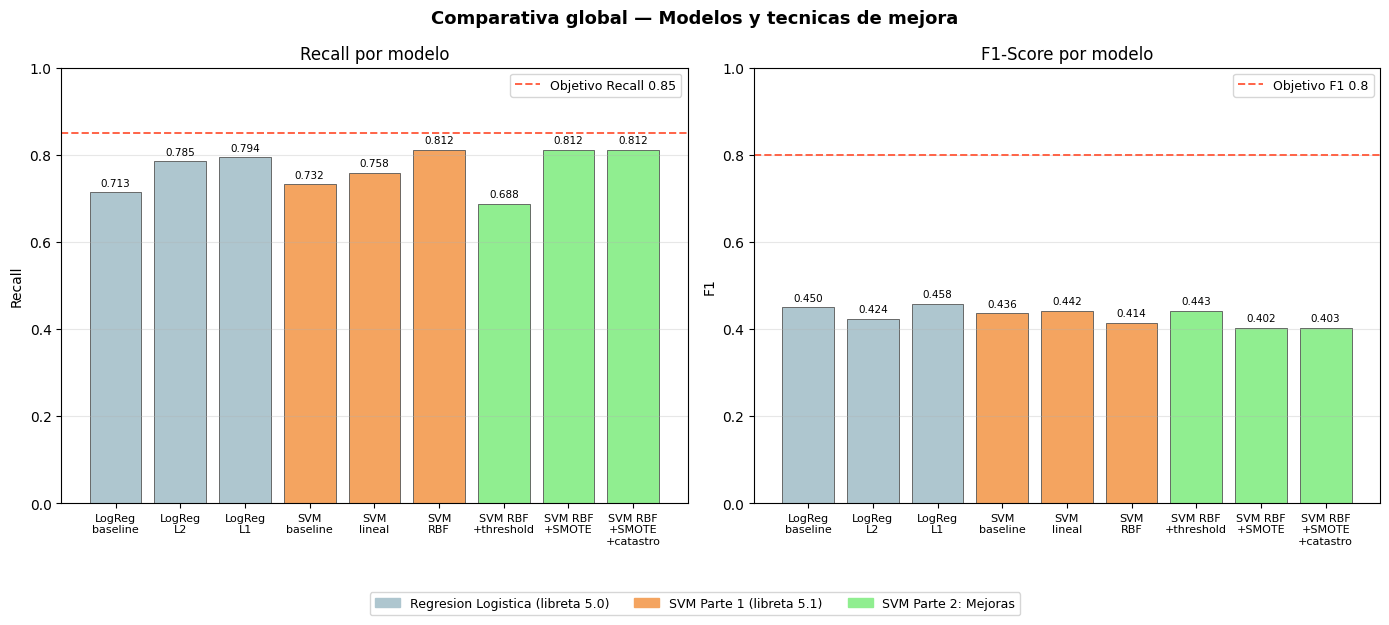

🏃 View run svm_comparativa_global_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/3a5bea74a9bc42a2b2777a8c41a1d325
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


Guardado en: reports/figures/svm_comparativa_global.png


In [18]:
# Figura: barras comparativas de Recall y F1 por modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

modelos_cortos = [
    'LogReg\nbaseline', 'LogReg\nL2', 'LogReg\nL1',
    'SVM\nbaseline', 'SVM\nlineal', 'SVM\nRBF',
    'SVM RBF\n+threshold', 'SVM RBF\n+SMOTE', 'SVM RBF\n+SMOTE\n+catastro'
]

colores = ['#aec6cf'] * 3 + ['#f4a460'] * 3 + ['#90ee90'] * 3

for ax, metrica, titulo, objetivo in zip(
    axes,
    ['Recall', 'F1'],
    ['Recall por modelo', 'F1-Score por modelo'],
    [0.85, 0.80]
):
    bars = ax.bar(modelos_cortos, df_global[metrica], color=colores, edgecolor='#555', linewidth=0.6)
    ax.axhline(objetivo, color='tomato', linestyle='--', linewidth=1.4,
               label=f'Objetivo {metrica} {objetivo}')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(metrica)
    ax.set_title(titulo)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5)

# Leyenda de grupos
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#aec6cf', label='Regresion Logistica (libreta 5.0)'),
    Patch(color='#f4a460', label='SVM Parte 1 (libreta 5.1)'),
    Patch(color='#90ee90', label='SVM Parte 2: Mejoras'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Comparativa global — Modelos y tecnicas de mejora', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.06, 1, 1])

ruta_global = 'reports/figures/svm/svm_comparativa_global.png'
fig.savefig(ruta_global, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_comparativa_global_artifact'):
    mlflow.log_artifact(ruta_global)

print(f'Guardado en: {ruta_global}')

## E. Conclusiones — Parte 2: Mejoras

Resultados de las tres tecnicas aplicadas al SVM RBF (C=0.1, gamma=scale, balanced):

| Modelo / Tecnica                        | Recall | F1    | AUC   | Mejor que base |
|-----------------------------------------|--------|-------|-------|----------------|
| SVM RBF base (Parte 1)                  | 0.812  | 0.414 | 0.757 | —              |
| SVM RBF + threshold tuning (thr=0.241)  | 0.688  | 0.443 | 0.746 | F1 si, Recall no |
| SVM RBF + SMOTE                         | 0.812  | 0.402 | 0.754 | No             |
| SVM RBF + SMOTE + catastro (21 feat)    | 0.812  | 0.403 | 0.743 | No             |

**Ninguna tecnica supero al SVM RBF base en todas las metricas.**

---

### Analisis de cada tecnica

**1. Threshold Tuning — resultado inesperado pero informativo**
El SVM con Platt scaling asigna probabilidades muy conservadoras a la clase positiva.
Con umbral 0.50, el modelo no predice ningun positivo (Recall=0.00), lo que significa
que las probabilidades de clase 1 nunca superan 0.50. El umbral optimo para F1 es 0.241,
con el que se obtiene Recall=0.688 y F1=0.443. Sin embargo, esto es peor en Recall que
el predict() por defecto (0.812), que usa el umbral de la funcion de decision del SVM,
no el de las probabilidades. Conclusion: el threshold de probabilidad y el umbral de
la funcion de decision son dos cosas distintas en SVM. El metodo predict() ya esta bien
calibrado para este modelo gracias al class_weight='balanced'.

**2. SMOTE — sin ganancia sobre el modelo base**
SMOTE no mejoró ni Recall ni F1; incluso bajo ligeramente el F1 (0.402 vs 0.414).
Con 112 ejemplos positivos reales y 5-fold CV, cada fold de entrenamiento tiene ~90
positivos. SMOTE los multiplica internamente, pero el SVM ya tiene suficiente senial
con class_weight='balanced' para encontrar una buena frontera. Agregar ejemplos
sinteticos en este caso solo agrega ruido sin nueva informacion.

**3. Feature Catastral — hipotesis no confirmada**
VALOR_CATASTRAL_MAX no mejoro el modelo (Recall=0.812, F1=0.403, practicamente igual).
Dos posibles razones: (a) el 20.2% de AGEBs sin valor catastral (rellenados con 0)
introduce ruido que cancela la ganancia; (b) el valor catastral esta correlacionado
con features que ya existen (GRAPROES, VPH_AUTOM, VPH_INTER), por lo que no agrega
informacion independiente. La hipotesis del abandono especulativo no queda refutada —
podria ser valida con datos catastrales completos (100% de cobertura).

---

### Conclusion final del trabajo de Francisco

El mejor modelo es el **SVM RBF sin mejoras adicionales** (C=0.1, gamma=scale, balanced),
con Recall=0.812 y F1=0.414. Supera a la regresion logistica en Recall (+1.8 pp) pero
ninguno alcanza los objetivos del proyecto.

El cuello de botella no es la tecnica sino el dataset: 112 casos positivos y un desbalance
5:1 limitan el techo de cualquier modelo. Los modelos de ensemble del equipo (Random Forest,
Gradient Boosting) operan de forma fundamentalmente distinta — combinan decenas de arboles
que pueden capturar interacciones complejas entre features — y se espera que superen estos
resultados. El reporte final elegira el mejor modelo entre los cuatro evaluados.

---

## F. Experimento adicional: Optimizando para F1

En todos los experimentos anteriores el GridSearchCV buscaba la combinacion de
hiperparametros que maximizaba **Recall**. Eso produce modelos que detectan la
mayor cantidad posible de zonas de riesgo, pero a costa de muchos falsos positivos,
lo que hunde la precision y, por tanto, el F1.

Este experimento cambia el criterio de busqueda a `scoring='f1'` y agrega pesos
de clase personalizados al grid para explorar el tradeoff Precision-Recall mas fino:

| class_weight | Ratio pos/neg | Efecto esperado |
|---|---|---|
| `None` | 1:1 | Modelo sesgado a clase mayoritaria, F1 bajo |
| `{0:1, 1:3}` | 3:1 | Menos agresivo que balanced, mas precision |
| `{0:1, 1:5}` | 5:1 | Equivale aproximadamente a 'balanced' |
| `'balanced'` | ~4.9:1 | Lo que usamos hasta ahora |
| `{0:1, 1:7}` | 7:1 | Mas agresivo que balanced, mas Recall |

**Pregunta que responde:** ¿Existe una configuracion que mejore F1 sin que Recall
caiga demasiado lejos de 0.85?

In [19]:
pipe_f1 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True, random_state=42))
])

param_grid_f1 = [
    {
        'clf__kernel':       ['rbf'],
        'clf__C':            [0.01, 0.1, 1, 10],
        'clf__gamma':        ['scale', 'auto'],
        'clf__class_weight': [None, 'balanced',
                              {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 7}],
    },
    {
        'clf__kernel':       ['linear'],
        'clf__C':            [0.01, 0.1, 1, 10],
        'clf__class_weight': [None, 'balanced',
                              {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 7}],
    },
]

# Scoring = f1: busca el mejor equilibrio precision-recall
grid_f1 = GridSearchCV(
    pipe_f1,
    param_grid_f1,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_f1.fit(X, y)

print(f'Mejores parametros (scoring=f1): {grid_f1.best_params_}')
print(f'Mejor F1 (CV):                   {grid_f1.best_score_:.4f}')

# Top 10 por F1
res_f1 = pd.DataFrame(grid_f1.cv_results_)
top10_f1 = (
    res_f1
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    [['param_clf__kernel', 'param_clf__C', 'param_clf__gamma',
      'param_clf__class_weight', 'mean_test_score', 'std_test_score']]
)
top10_f1.columns = ['kernel', 'C', 'gamma', 'class_weight', 'f1_mean', 'f1_std']
top10_f1 = top10_f1.round(4).reset_index(drop=True)
print('\nTop 10 combinaciones por F1:')
print(top10_f1.to_string(index=False))

Mejores parametros (scoring=f1): {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}
Mejor F1 (CV):                   0.4630

Top 10 combinaciones por F1:
kernel    C gamma class_weight  f1_mean  f1_std
linear  1.0   NaN     balanced   0.4630  0.0562
linear 10.0   NaN {0: 1, 1: 5}   0.4595  0.0582
linear 10.0   NaN {0: 1, 1: 3}   0.4593  0.0610
linear  1.0   NaN {0: 1, 1: 5}   0.4589  0.0591
linear  0.1   NaN {0: 1, 1: 5}   0.4563  0.0585
linear 10.0   NaN     balanced   0.4500  0.0566
linear  0.1   NaN     balanced   0.4418  0.0498
   rbf  1.0 scale     balanced   0.4365  0.0462
   rbf  1.0 scale {0: 1, 1: 5}   0.4349  0.0495
   rbf  1.0  auto {0: 1, 1: 5}   0.4327  0.0453


In [20]:
bp_f1 = grid_f1.best_params_

# Reconstruir el mejor modelo segun F1
if bp_f1['clf__kernel'] == 'rbf':
    mejor_f1_model = make_pipeline(
        kernel=bp_f1['clf__kernel'],
        C=bp_f1['clf__C'],
        gamma=bp_f1['clf__gamma'],
        class_weight=bp_f1['clf__class_weight']
    )
else:
    mejor_f1_model = make_pipeline(
        kernel=bp_f1['clf__kernel'],
        C=bp_f1['clf__C'],
        class_weight=bp_f1['clf__class_weight']
    )

metricas_f1 = evaluar_modelo(mejor_f1_model, X, y)

params_log_f1 = {
    'kernel':       bp_f1['clf__kernel'],
    'C':            bp_f1['clf__C'],
    'gamma':        str(bp_f1.get('clf__gamma', 'N/A')),
    'class_weight': str(bp_f1['clf__class_weight']),
    'scoring':      'f1',
}
log_experimento('svm_optimizado_f1', mejor_f1_model, params_log_f1, metricas_f1)

print('=== Mejor SVM optimizado para F1 ===')
print(f"  Recall:  {metricas_f1['recall_mean']:.4f} +/- {metricas_f1['recall_std']:.4f}")
print(f"  F1:      {metricas_f1['f1_mean']:.4f} +/- {metricas_f1['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_f1['auc_mean']:.4f} +/- {metricas_f1['auc_std']:.4f}")

print('\n--- Comparacion vs mejor SVM anterior (scoring=recall) ---')
print(f"  Recall:  0.8119 → {metricas_f1['recall_mean']:.4f}  "
      f"({'sube' if metricas_f1['recall_mean'] > 0.8119 else 'baja'})")
print(f"  F1:      0.4141 → {metricas_f1['f1_mean']:.4f}  "
      f"({'sube' if metricas_f1['f1_mean'] > 0.4141 else 'baja'})")
print(f"  AUC:     0.7566 → {metricas_f1['auc_mean']:.4f}  "
      f"({'sube' if metricas_f1['auc_mean'] > 0.7566 else 'baja'})")

2026/05/08 11:49:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:49:47 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:49:57 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:57 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:49:57 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:49:57 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:49:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_optimizado_f1 at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/0595d403df2b401c96f7e3fa0df51295
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_optimizado_f1' registrado — Recall: 0.740 | F1: 0.463 | AUC: 0.766
=== Mejor SVM optimizado para F1 ===
  Recall:  0.7399 +/- 0.1147
  F1:      0.4630 +/- 0.0562
  AUC-ROC: 0.7659 +/- 0.0768

--- Comparacion vs mejor SVM anterior (scoring=recall) ---
  Recall:  0.8119 → 0.7399  (baja)
  F1:      0.4141 → 0.4630  (sube)
  AUC:     0.7566 → 0.7659  (sube)


In [21]:
# Tabla final con el experimento F1 incluido
resultados_con_f1 = resultados_globales + [
    {
        'Modelo': f'SVM {bp_f1["clf__kernel"].upper()} optimizado F1 (scoring=f1)',
        'Recall': metricas_f1['recall_mean'],
        'F1':     metricas_f1['f1_mean'],
        'AUC':    metricas_f1['auc_mean'],
    }
]

df_final = pd.DataFrame(resultados_con_f1).set_index('Modelo')
df_final['Recall>=0.85'] = df_final['Recall'].apply(lambda x: 'SI' if x >= 0.85 else '—')
df_final['F1>=0.80']     = df_final['F1'].apply(lambda x: 'SI' if x >= 0.80 else '—')
df_final['AUC>=0.85']    = df_final['AUC'].apply(lambda x: 'SI' if x >= 0.85 else '—')

print('=== Tabla final — todos los experimentos incluyendo optimizacion F1 ===')
print(df_final.round(4).to_string())
print()
print(f'Mejor Recall: {df_final["Recall"].idxmax()} ({df_final["Recall"].max():.4f})')
print(f'Mejor F1:     {df_final["F1"].idxmax()} ({df_final["F1"].max():.4f})')
print(f'Mejor AUC:    {df_final["AUC"].idxmax()} ({df_final["AUC"].max():.4f})')

=== Tabla final — todos los experimentos incluyendo optimizacion F1 ===
                                       Recall      F1     AUC Recall>=0.85 F1>=0.80 AUC>=0.85
Modelo                                                                                       
LogReg baseline (L2, C=1, balanced)    0.7134  0.4499  0.7726            —        —         —
LogReg mejor L2 (C=0.01, balanced)     0.7850  0.4239  0.7678            —        —         —
LogReg mejor L1 (C=0.1, balanced)      0.7941  0.4579  0.7707            —        —         —
SVM baseline (RBF, C=1, balanced)      0.7320  0.4365  0.7604            —        —         —
SVM mejor lineal (C=0.1, balanced)     0.7581  0.4418  0.7721            —        —         —
SVM mejor RBF (C=0.1, balanced)        0.8119  0.4141  0.7566            —        —         —
SVM RBF + threshold tuning             0.6875  0.4425  0.7459            —        —         —
SVM RBF + SMOTE                        0.8119  0.4024  0.7537            —        

### Conclusion del experimento F1

Resultado obtenido con `scoring='f1'`:

| Modelo | Recall | F1 | AUC |
|---|---|---|---|
| SVM RBF base (scoring=recall) | **0.812** | 0.414 | 0.757 |
| SVM Linear optimizado F1 (C=1, balanced) | 0.740 | **0.463** | 0.766 |
| LogReg L1 referencia | 0.794 | 0.458 | 0.771 |

**Hay mejora en F1, pero con un costo real en Recall.**

El mejor modelo con `scoring='f1'` resulto ser un **kernel lineal** (C=1, balanced),
no RBF. Obtuvo F1=0.463 — el F1 mas alto de todos los experimentos del SVM — pero
Recall bajo a 0.740, una caida de 7.2 puntos porcentuales respecto al SVM RBF base.

Curiosamente, este resultado es casi identico a la regresion logistica L1 (F1=0.458,
Recall=0.794): ambos modelos lineales convergen a la misma solucion cuando optimizan
para F1, lo que confirma que el problema tiene un componente predominantemente lineal.

**Decision para el reporte final:**

- Si lo mas importante es **no perder zonas de riesgo** (minimizar falsos negativos):
  usar **SVM RBF** (Recall=0.812, F1=0.414)
- Si se necesita **balance entre precision y cobertura**:
  usar **SVM Linear optimizado F1** (Recall=0.740, F1=0.463)

Para politica publica de vivienda, donde un falso negativo significa dejar sin
atencion una zona en riesgo, la recomendacion es el **SVM RBF**. El F1 bajo refleja
que el modelo genera algunos falsos positivos, pero es preferible a dejar zonas
de alto riesgo sin detectar.